## Caso 1.- Apunte de la clase 31/08/26

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

Se utiliza la palabra DF para definir la funcion que leera toda la dataset en la nombleglatura 

In [2]:
df= pd.read_csv("healthcare_dataset.csv")


Utilizamos la funcion .head para saber todos los cabezales de la base de datos 

In [3]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


Shape nos da el registro total de registros y la cantidad de columnas que tenemos 

In [4]:
df.shape

(55500, 15)

El .info nos da todos los datos de nuestros atributos 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


Ahora .describe nos da la descripcion total de todos los campos necesarios que tenemos en nuestra dataset 

In [6]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


.isnull nos da todos los registros nulos o varios de nuestros atributos

In [7]:
df.isnull().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

Importamos la libreria missingno y msmo para la graficacion de los valores nulos

In [8]:
import missingno as msno

<Axes: >

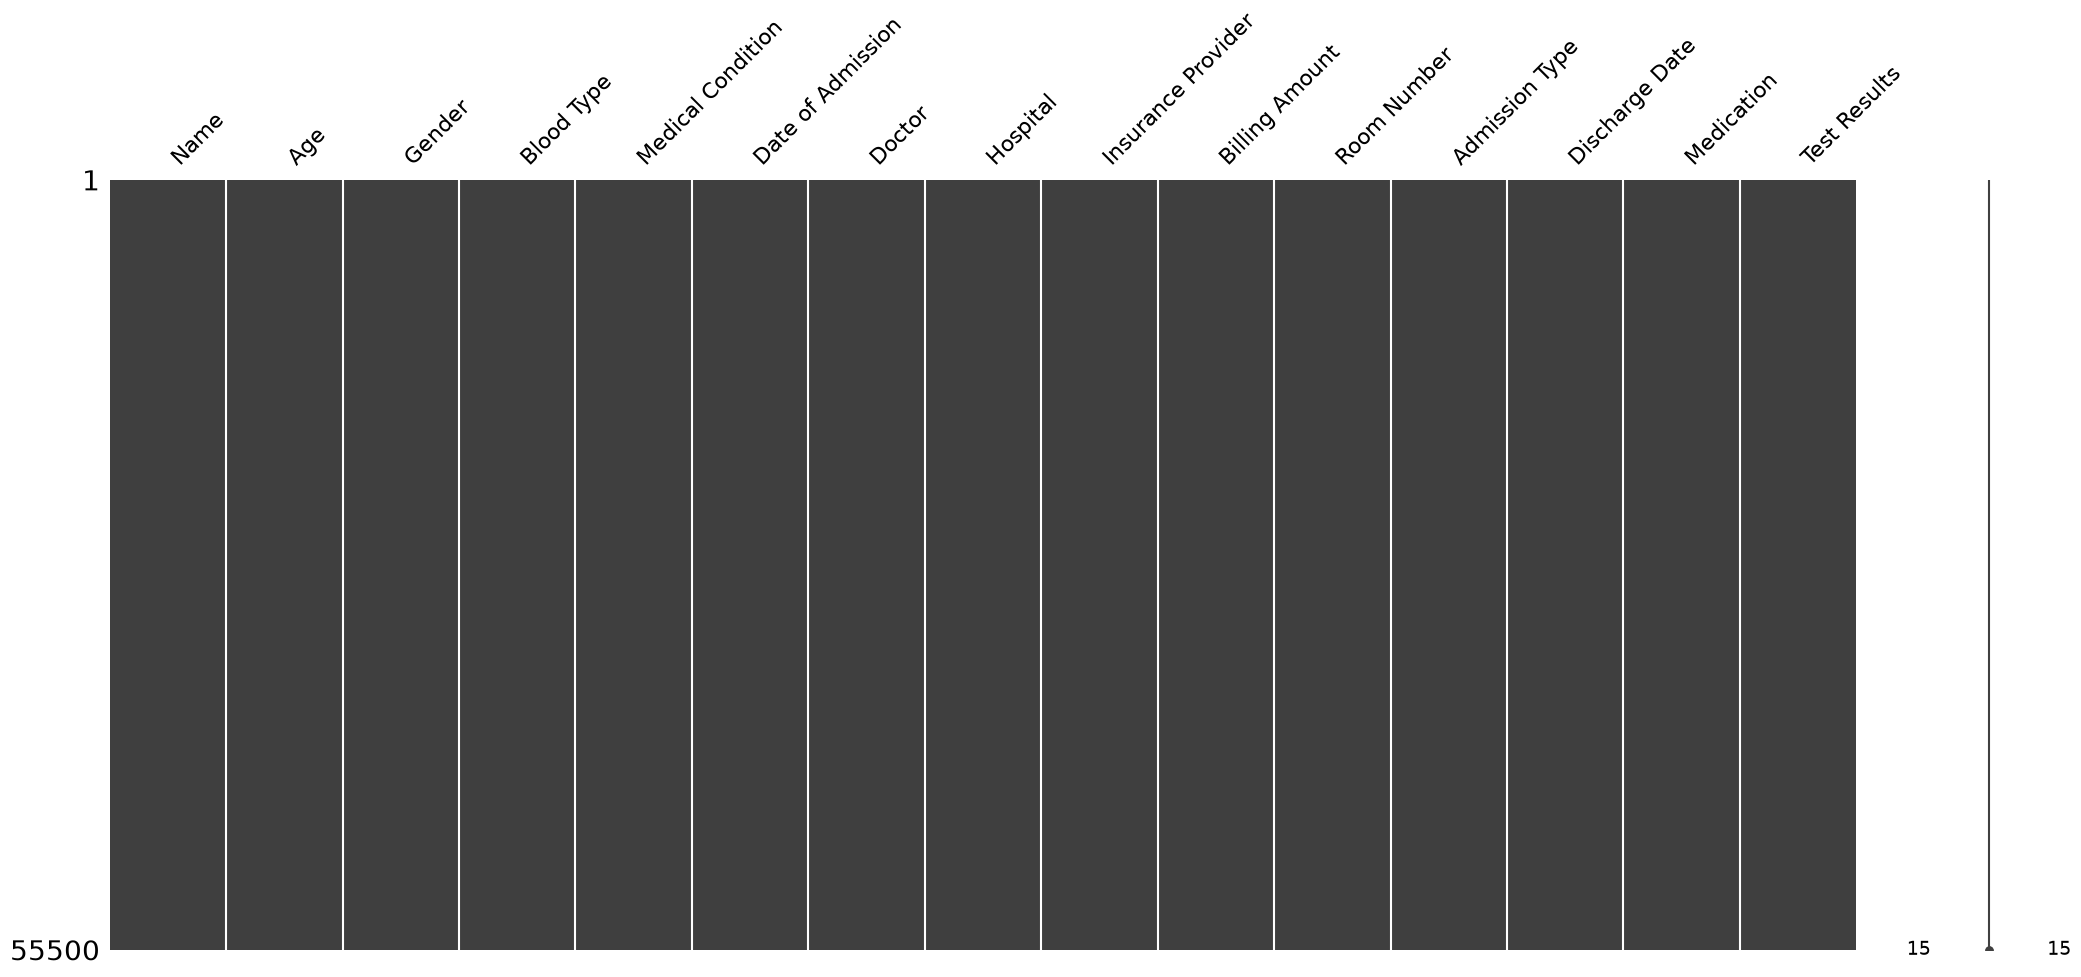

In [9]:
msno.matrix(df)

In [10]:
df["Medical Condition"].fillna(
    df["Medical Condition"].mode()[0], 
    inplace=True
)

C:\Users\Eimy\AppData\Local\Temp\ipykernel_15304\879607300.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Medical Condition"].fillna(


0              Cancer
1             Obesity
2             Obesity
3            Diabetes
4              Cancer
             ...     
55495          Asthma
55496         Obesity
55497    Hypertension
55498       Arthritis
55499       Arthritis
Name: Medical Condition, Length: 55500, dtype: str

In [11]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

En este caso ponemos que dato queremos saber en especifico de mi Dataset

In [12]:
df[df["Medical Condition"]=="Cancer"]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive
10,mIchElLe daniELs,72,Male,O+,Cancer,2020-04-19,John Duncan,Schaefer-Porter,Medicare,12576.795609,394,Urgent,2020-04-22,Paracetamol,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55448,tIFfANy miller,78,Male,B-,Cancer,2023-06-22,Jaime Valdez,Sons Williams and,UnitedHealthcare,17217.325440,287,Urgent,2023-06-30,Ibuprofen,Inconclusive
55456,DEBRa MIller,17,Male,AB-,Cancer,2021-07-29,Samantha Russell,Collier-Jordan,UnitedHealthcare,43230.028453,125,Urgent,2021-08-01,Ibuprofen,Abnormal
55479,mIcHAeL SanTiAgo,58,Female,B-,Cancer,2022-01-05,Andrea Fields,Berry-Nguyen,Medicare,45767.175201,299,Elective,2022-01-29,Ibuprofen,Normal
55484,keNNEtH alvarez,80,Male,O+,Cancer,2022-05-05,Andrew Conner,Sons Mayo and,Cigna,45653.802310,114,Elective,2022-05-17,Aspirin,Normal


y aca definimos otro dato

In [13]:
df[df["Gender"]=="Male"]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
10,mIchElLe daniELs,72,Male,O+,Cancer,2020-04-19,John Duncan,Schaefer-Porter,Medicare,12576.795609,394,Urgent,2020-04-22,Paracetamol,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55489,ANdrEw AGUIlaR,69,Male,O-,Arthritis,2019-06-25,Dustin Pearson,"and Barry White, Jones",Medicare,41893.245150,171,Urgent,2019-07-09,Paracetamol,Normal
55490,STepHAniE oliVer,82,Male,B-,Cancer,2022-01-10,Gary Leblanc,Group Lee,Cigna,17350.543524,381,Emergency,2022-01-21,Penicillin,Abnormal
55492,LAuREn MCcormIcK,51,Male,O+,Arthritis,2020-12-06,Kevin Flores,Inc Barnett,Cigna,2588.150832,289,Emergency,2020-12-12,Paracetamol,Normal
55494,JEssIcA WHiTe,67,Male,O+,Arthritis,2023-12-11,Jesus Jordan,Miller-Harris,Medicare,42535.301234,378,Emergency,2024-01-04,Ibuprofen,Normal


y de nuestra muestra aleatoria y recapitulamos un total de 50 muestras aleatorias 

In [14]:
muestra = df.sample(
    n=50,
    random_state=42
)

muestra

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
31641,mIchAEl thOrnTon mD,57,Male,O+,Diabetes,2023-09-15,Jason Hanson,Thornton-Roy,Medicare,3616.898450,339,Elective,2023-10-02,Aspirin,Inconclusive
9246,mattheW HUTcHiNsOn,51,Female,A+,Diabetes,2023-10-07,Jesse Gonzalez,Wilkerson-Lewis,Aetna,36970.075481,372,Emergency,2023-10-14,Penicillin,Abnormal
1583,RoNald paRK,20,Male,A+,Asthma,2019-09-09,Sarah Hernandez,Brown-Hughes,Blue Cross,44393.001348,148,Elective,2019-10-08,Penicillin,Inconclusive
36506,Jeff BroOkS,74,Female,B+,Obesity,2020-09-14,Cathy Sanchez,"Wilson, Alexander Wolf and",Aetna,27554.923708,135,Emergency,2020-09-21,Ibuprofen,Abnormal
11259,TAnya THoMPsOn,56,Male,AB-,Obesity,2023-02-01,Nancy Lee,"Winters, Blackburn Chandler and",Aetna,27466.318567,284,Emergency,2023-02-07,Paracetamol,Inconclusive
8972,EThan MItcHELL,46,Male,B+,Cancer,2021-12-30,Christina Hart,Rocha-Wagner,Medicare,4802.620714,175,Elective,2022-01-27,Paracetamol,Abnormal
36078,AMBer WRiGHt,44,Female,O+,Asthma,2023-05-13,Melissa Stephens,Friedman-Douglas,Blue Cross,40207.463218,336,Elective,2023-06-09,Paracetamol,Inconclusive
42659,mORGAn lAWreNce,46,Male,B-,Diabetes,2023-06-20,Paul Hansen,"Wells and Davila Cooper,",Medicare,30065.260598,212,Elective,2023-07-16,Ibuprofen,Abnormal
6545,MackEnZiE MAxwEll,64,Female,AB-,Arthritis,2019-08-03,Thomas Pratt,"and Alvarez, Cox Powers",Cigna,392.913548,113,Urgent,2019-08-15,Ibuprofen,Inconclusive
35448,Cindy ROGeRS,68,Male,B-,Cancer,2022-03-15,Calvin George,"Conley Jackson, and Hill",Medicare,20886.342148,274,Urgent,2022-04-14,Penicillin,Normal


y hacemos que nos describa la muestra 

In [15]:
muestra.describe()

,Age,Billing Amount,Room Number
count,50.000000,50.000000,50.000000
mean,54.700000,20894.296932,310.480000
std,19.645065,13888.817582,112.610262
min,19.000000,392.913548,113.000000
25%,38.750000,7808.898315,215.000000
50%,57.000000,20494.592375,312.000000
75%,70.500000,30097.267577,386.000000
max,85.000000,47749.017060,491.000000


Es de toda nuestra informacion del inicio

In [16]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


Este sera enfocado a nuestros 50 datos que pusimos

In [17]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

In [18]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,0,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,0,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,1,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,1,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,1,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


Hacemos que nos genere un minimo maximo y maximo

In [19]:
scaler = MinMaxScaler()

df[["Age","Gender"]] = scaler.fit_transform(
    df[["Age","Gender"]]
)

In [20]:
df[["Age", "Gender"]].head()

,Age,Gender
0,0.223684,0.0
1,0.644737,0.0
2,0.828947,1.0
3,0.197368,1.0
4,0.394737,1.0


y graficamos 

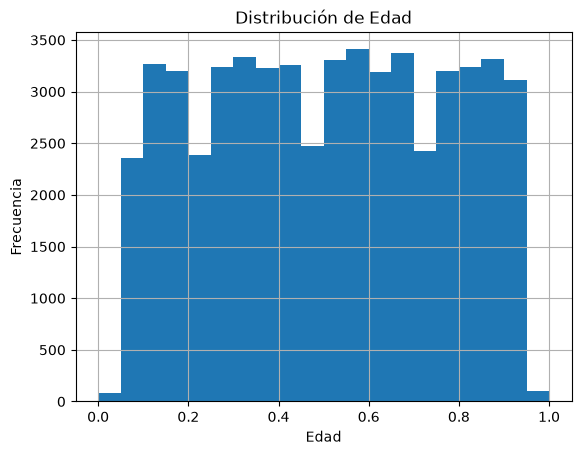

In [21]:
df["Age"].hist(
    bins=20
    )

plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

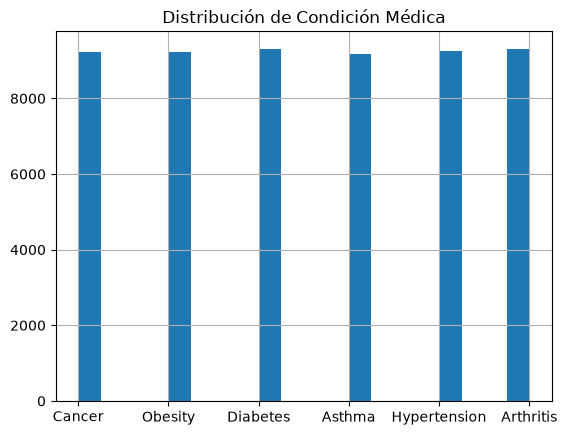

In [22]:
df["Medical Condition"].hist(
    bins=20
)

plt.title("Distribución de Condición Médica")
plt.show()

In [23]:
df["Gender"] = df["Gender"].map({
    "Male":0,
    "Female":1
})

In [37]:
datos = df[
    ["Age", "Gender", "Medical Condition"]
]

Volvemos a generar los valores nulos o vacios

In [25]:
datos.isnull().sum()

Age                      0
Gender               55500
Medical Condition        0
dtype: int64

y imprimimos los valores y los tipos de dato que tienen esos datos

In [26]:
print("TIPOS DE DATOS")
print(datos.dtypes)

print("VALORES ÚNICOS")
print(datos.isnull().sum())

print("PRIMEROS REGISTROS")
print(datos.head())

TIPOS DE DATOS
Age                  float64
Gender               float64
Medical Condition        str
dtype: object
VALORES ÚNICOS
Age                      0
Gender               55500
Medical Condition        0
dtype: int64
PRIMEROS REGISTROS
        Age  Gender Medical Condition
0  0.223684     NaN            Cancer
1  0.644737     NaN           Obesity
2  0.828947     NaN           Obesity
3  0.197368     NaN          Diabetes
4  0.394737     NaN            Cancer


Para generar 10 datos 

In [27]:
datos.iloc[:10]

,Age,Gender,Medical Condition
0,0.223684,NaN,Cancer
1,0.644737,NaN,Obesity
2,0.828947,NaN,Obesity
3,0.197368,NaN,Diabetes
4,0.394737,NaN,Cancer
5,0.302632,NaN,Asthma
6,0.105263,NaN,Diabetes
7,0.092105,NaN,Cancer
8,0.907895,NaN,Asthma
9,0.592105,NaN,Cancer


In [28]:
df = pd.read_csv("healthcare_dataset.csv")

In [29]:
df["Gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [30]:
df["Gender"] = df["Gender"].map({
    "Male": 0,
    "Female": 1
})

In [31]:
df["Gender"].unique()

array([0, 1])

In [32]:
df["Gender"] = df["Gender"].fillna(
    df["Gender"].median()
)

In [33]:
df[["Age","Gender"]].isnull().sum()

Age       0
Gender    0
dtype: int64

In [35]:
from sklearn.metrics.pairwise import cosine_similarity

datos = df[
    ["Age",
     "Gender",
     "Medical Condition",
     "Pclass"]
]

similitud = cosine_similarity(
    datos.iloc[:10]
)

KeyError: "['Pclass'] not in index"